# Face Detection & Recognition Pipeline

In [7]:
import sys
from pathlib import Path
import os

# Add project root to Python path
# Detect if we're in notebooks/ directory and adjust accordingly
current_dir = Path(os.getcwd()).resolve()
if current_dir.name == 'notebooks':
    # Running from notebooks/ directory, go up one level
    project_root = current_dir.parent
else:
    # Running from project root or elsewhere, try relative path
    project_root = Path('..').resolve() if (Path('.') / 'notebooks').exists() else current_dir

# Add to path if not already there
project_root_str = str(project_root.resolve())
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Import all required modules
from src.data_loader import load_wider_face, load_custom_pascal_voc
from src.dataset_wrapper import FaceDataset
from src.face_detector import HaarFaceDetector, YOLOFaceDetector, visualize_detections
from src.face_recognizer import FaceRecognizer
from src.preprocessing import resize_and_normalize, augment_image

## 1. Project Configuration


In [8]:
from dataclasses import dataclass

@dataclass
class PipelineConfig:
    project_root: Path = Path('..').resolve()
    data_dir: Path = project_root / 'data'
    raw_dir: Path = data_dir / 'raw'
    annotations_dir: Path = data_dir / 'annotations'
    reference_dir: Path = data_dir / 'reference'
    processed_dir: Path = data_dir / 'processed'
    wider_split: str = 'train'
    batch_size: int = 4
    image_size: tuple[int, int] = (512, 512)
    yolo_model: str = 'yolov8n.pt'
    yolo_epochs: int = 25
    yolo_data_cfg: Path = data_dir / 'face_yolo.yaml'

cfg = PipelineConfig()
cfg


PipelineConfig(project_root=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline'), data_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data'), raw_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/raw'), annotations_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/annotations'), reference_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/reference'), processed_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/processed'), wider_split='train', batch_size=4, image_size=(512, 512), yolo_model='yolov8n.pt', yolo_epochs=25, yolo_data_cfg=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/face_yolo.yaml'))

## 2. Dataset Loading & Preprocessing
We reuse the TFDS pipeline from Assignment 3 for WIDER FACE and the Pascal VOC loader for custom images of the target person.


In [13]:
# Load WIDER FACE dataset
# The loader will automatically fall back to loading from extracted files if TFDS has download issues
wider_ds = load_wider_face(
    split=cfg.wider_split,
    data_dir=cfg.data_dir,
    batch_size=cfg.batch_size,
    image_size=cfg.image_size,
    download_mode='reuse_cache_if_exists',  # Tries to use existing downloads, falls back to direct loading if needed
)

# Load custom Pascal VOC dataset
custom_ds = load_custom_pascal_voc(
    images_dir=cfg.raw_dir,
    annotations_dir=cfg.annotations_dir,
    image_size=cfg.image_size,
)

wider_ds, custom_ds


/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/src/data_loader.py:199: UserWarning: Dataset not prepared yet. Will attempt to prepare using existing downloads.
  warnings.warn(


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...:  75%|███████▌  | 3/4 [00:00<00:00, 114.53 url/s]
Extraction completed...: 0 file [00:00, ? file/s]
Dl Completed...:  75%|███████▌  | 3/4 [00:00<00:00,  3.93 url/s] 
/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/src/data_loader.py:424: UserWarning: TFDS download failed. Attempting to load directly from extracted files...
  warnings.warn(
/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/src/data_loader.py:431: UserWarning: Successfully loaded dataset from extracted files (without annotations).
Note: Bounding boxes are empty. To load with annotations, ensure annotation files are available.
  warnings.warn(


(<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name=None), 'bboxes': TensorSpec(shape=(None, None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None, None), dtype=tf.int32, name=None)}>,
 <_FlatMapDataset element_spec={'image': TensorSpec(shape=(512, 512, 3), dtype=tf.float32, name=None), 'bboxes': TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None,), dtype=tf.int32, name=None), 'image_id': TensorSpec(shape=(), dtype=tf.string, name=None)}>)

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 52.9M/52.9M [00:20<00:00, 2.77MB/s]

Extracting files...


Path to dataset files: /Users/sarangsawant/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1


## 2.5. Generate YOLO Labels (if not already created)

If you don't have YOLO format label files (.txt), you can automatically generate them by detecting faces in your images.

**YOLO Label Format:**
- Each image needs a corresponding `.txt` file with the same name
- Format: `class_id center_x center_y width height` (all normalized 0-1)
- Example: `0 0.5 0.5 0.3 0.4` means a face at center with 30% width and 40% height

**Options:**
1. **Automatic detection** (recommended): Use the script below to detect faces and generate labels
2. **Manual annotation**: Use tools like LabelImg, CVAT, or Roboflow to manually annotate
3. **Use existing annotations**: Convert from Pascal VOC XML or other formats


In [ ]:
# Generate YOLO labels automatically by detecting faces
# This will:
# 1. Detect faces in all images in cfg.raw_dir (including subdirectories)
# 2. Generate .txt label files in YOLO format
# 3. Organize images into train/val splits
# 4. Copy images and labels to data/raw/train/ and data/raw/val/

import subprocess
import sys
from pathlib import Path

# Run the label generation script
script_path = cfg.project_root / "generate_yolo_labels.py"

if script_path.exists():
    print("Generating YOLO labels...")
    print("This may take a while depending on the number of images.")
    
    # Run with Haar Cascade (fast, no GPU needed)
    result = subprocess.run(
        [
            sys.executable,
            str(script_path),
            "--input", str(cfg.raw_dir),
            "--output-images", str(cfg.raw_dir),
            "--output-labels", str(cfg.raw_dir),
            "--method", "haar",  # Use "yolo" if you have a face detection model
            "--train-split", "0.8",
        ],
        capture_output=True,
        text=True
    )
    
    if result.returncode == 0:
        print("✅ Labels generated successfully!")
        print(result.stdout)
    else:
        print("❌ Error generating labels:")
        print(result.stderr)
        print("\nYou can also run this from terminal:")
        print(f"  python {script_path} --input {cfg.raw_dir} --method haar")
else:
    print(f"⚠️  Script not found at {script_path}")
    print("You can manually create labels or use annotation tools like LabelImg.")


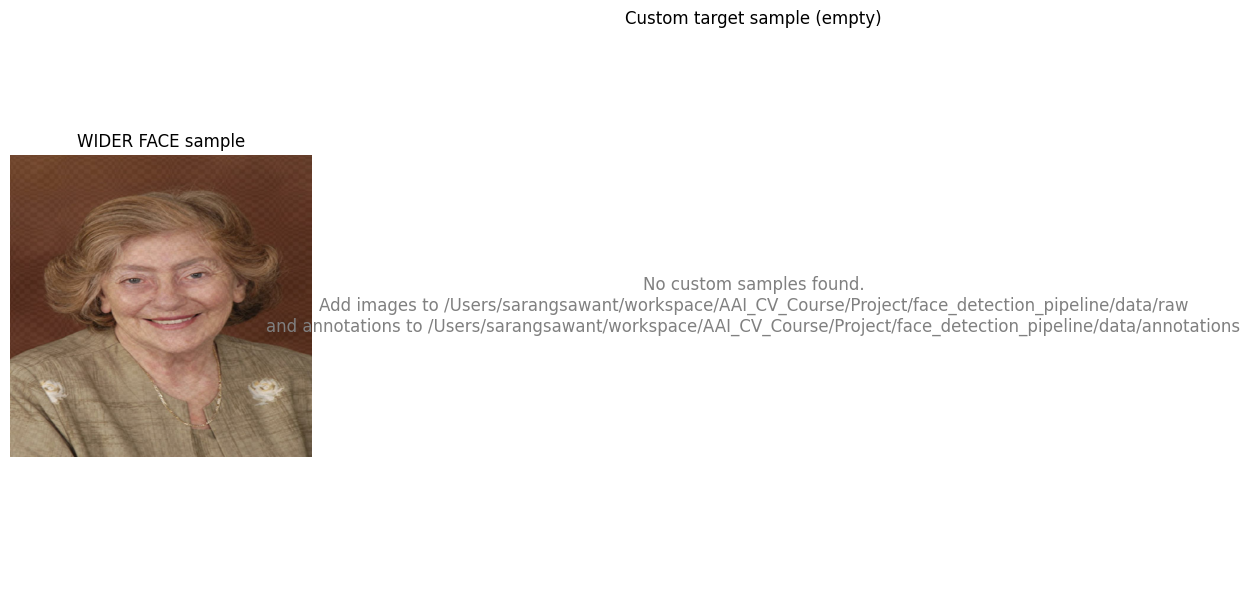

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize WIDER FACE sample
sample = next(iter(wider_ds.take(1)))
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display WIDER FACE sample
wider_image = sample['image'][0].numpy()
# Ensure image is in [0, 1] range for display
if wider_image.max() > 1.0:
    wider_image = wider_image / 255.0
axes[0].imshow(wider_image)
axes[0].set_title('WIDER FACE sample')
axes[0].axis('off')

# Check if custom dataset has samples
custom_iter = iter(custom_ds.take(1))
try:
    custom_sample = next(custom_iter)
    custom_image = custom_sample['image'].numpy()
    # Ensure image is in [0, 1] range for display
    if custom_image.max() > 1.0:
        custom_image = custom_image / 255.0
    axes[1].imshow(custom_image)
    axes[1].set_title('Custom target sample')
except StopIteration:
    # Custom dataset is empty - show placeholder message
    axes[1].text(0.5, 0.5, 
                 'No custom samples found.\n'
                 f'Add images to {cfg.raw_dir}\n'
                 f'and annotations to {cfg.annotations_dir}',
                 ha='center', va='center', 
                 fontsize=12, color='gray',
                 transform=axes[1].transAxes)
    axes[1].set_title('Custom target sample (empty)')
except Exception as e:
    # Handle other exceptions (e.g., OutOfRangeError from TensorFlow)
    if 'OutOfRange' in str(type(e).__name__) or 'End of sequence' in str(e):
        axes[1].text(0.5, 0.5, 
                     'No custom samples found.\n'
                     f'Add images to {cfg.raw_dir}\n'
                     f'and annotations to {cfg.annotations_dir}',
                     ha='center', va='center', 
                     fontsize=12, color='gray',
                     transform=axes[1].transAxes)
        axes[1].set_title('Custom target sample (empty)')
    else:
        # Re-raise if it's a different error
        raise
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 3. Detector Training (YOLOv8 fine-tuning)
Export the custom dataset to YOLO format (images + label txt) under `data/raw/train|val` before running.


In [16]:
from ultralytics import YOLO

if not cfg.yolo_data_cfg.exists():
    raise FileNotFoundError(f"Missing YOLO data config at {cfg.yolo_data_cfg}")

model = YOLO(cfg.yolo_model)
train_results = model.train(
    data=str(cfg.yolo_data_cfg),
    epochs=cfg.yolo_epochs,
    imgsz=cfg.image_size[0],
    project=str(cfg.project_root / 'results'),
    name='yolo_face_tuned',
)
train_results


New https://pypi.org/project/ultralytics/8.3.230 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.229 🚀 Python-3.12.10 torch-2.9.1 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/face_yolo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=F

RuntimeError: Dataset '/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/face_yolo.yaml' error ❌ Dataset '/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/face_yolo.yaml' images not found, missing path '/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/data/raw/val/images'
Note dataset download directory is '/Users/sarangsawant/datasets'. You can update this in '/Users/sarangsawant/Library/Application Support/Ultralytics/settings.json'

## 4. Evaluation
Run validation on the held-out split to compute mAP and visualize predictions.


In [ ]:
val_results = model.val(
    data=str(cfg.yolo_data_cfg),
    imgsz=cfg.image_size[0],
    conf=0.25,
)
val_results


## 5. Specific Person Recognition
Use the fine-tuned detector to crop faces, then match embeddings against the target identity reference set.


In [ ]:
import glob

face_recognizer = FaceRecognizer()
reference_images = glob.glob(str(cfg.reference_dir / '*.jpg'))
if not reference_images:
    raise FileNotFoundError(f"Place reference images in {cfg.reference_dir}")

for ref_img in reference_images:
    face_recognizer.add_reference_image(name='target_person', image_path=ref_img)

inference_model = YOLO(cfg.project_root / 'results/yolo_face_tuned/weights/best.pt')
input_image_path = cfg.raw_dir / 'inference.jpg'  # Update with actual file
if not input_image_path.exists():
    raise FileNotFoundError(f"Provide an inference image at {input_image_path}")

image_bgr = cv2.imread(str(input_image_path))
yolo_detections = inference_model.predict(image_bgr, conf=0.25, verbose=False)
visualized = image_bgr.copy()

for result in yolo_detections:
    if result.boxes is None:
        continue
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = image_bgr[y1:y2, x1:x2]
        matches = face_recognizer.match(crop)
        label = 'unknown'
        score = 0.0
        if matches:
            label = matches[0]['name']
            score = matches[0]['score']
        cv2.rectangle(visualized, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(visualized, f"{label}:{score:.2f}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(visualized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Inference result with identity confirmation')
plt.show()
